# Spam Classification

## Data Import

In [2]:
import pandas as pd

In [7]:
columns = [
"word_freq_make",
"word_freq_address",
"word_freq_all",
"word_freq_3d",
"word_freq_our",
"word_freq_over",
"word_freq_remove",
"word_freq_internet",
"word_freq_order",
"word_freq_mail",
"word_freq_receive",
"word_freq_will",
"word_freq_people",
"word_freq_report",
"word_freq_addresses",
"word_freq_free",
"word_freq_business",
"word_freq_email",
"word_freq_you",
"word_freq_credit",
"word_freq_your",
"word_freq_font",
"word_freq_000",
"word_freq_money",
"word_freq_hp",
"word_freq_hpl",
"word_freq_george",
"word_freq_650",
"word_freq_lab",
"word_freq_labs",
"word_freq_telnet",
"word_freq_857",
"word_freq_data",
"word_freq_415",
"word_freq_85",
"word_freq_technology",
"word_freq_1999",
"word_freq_parts",
"word_freq_pm",
"word_freq_direct",
"word_freq_cs",
"word_freq_meeting",
"word_freq_original",
"word_freq_project",
"word_freq_re",
"word_freq_edu",
"word_freq_table",
"word_freq_conference",
"char_freq_;",
"char_freq_(",
"char_freq_[",
"char_freq_!",
"char_freq_$",
"char_freq_#",
"capital_run_length_average",
"capital_run_length_longest",
"capital_run_length_total",
"Spam"
]

In [9]:
data = pd.read_csv("spambase.data", header=None, names=columns)

In [10]:
data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


## Exploratory Data Analysis

In [11]:
data.info() # - No Null Values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [12]:
data.duplicated() #Check for Duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Length: 4601, dtype: bool

In [13]:
data.duplicated().any() #any() method outputs True if there's atleast one True Value, else outputs False

np.True_

In [14]:
duplicate_index = data.duplicated()
duplicate_index

0       False
1       False
2       False
3       False
4       False
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Length: 4601, dtype: bool

In [15]:
data.loc[duplicate_index]

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Spam
26,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.196,0.000,0.392,0.196,0.0,5.466,22,82,1
103,0.0,0.0,0.64,0.0,0.0,0.64,0.0,0.0,0.0,0.0,...,0.094,0.189,0.284,0.662,0.000,0.0,10.068,131,292,1
104,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.305,0.611,0.000,1.529,0.000,0.0,5.500,22,66,1
105,0.0,0.0,0.64,0.0,0.0,0.64,0.0,0.0,0.0,0.0,...,0.094,0.189,0.284,0.662,0.000,0.0,10.068,131,292,1
106,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.305,0.611,0.000,1.529,0.000,0.0,5.500,22,66,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4439,0.0,0.0,0.74,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.036,0.147,0.000,0.147,0.000,0.0,2.587,55,282,0
4441,0.0,0.0,0.74,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.036,0.147,0.000,0.147,0.000,0.0,2.587,55,282,0
4537,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,1,6,0
4541,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.000,0.000,0.000,0.000,0.000,0.0,1.000,1,2,0


In [22]:
cleaned_data = data.drop_duplicates()
cleaned_data

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [18]:
len(data)

4601

In [23]:
len(cleaned_data)

4210

In [24]:
len(data) - len(cleaned_data)

391

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

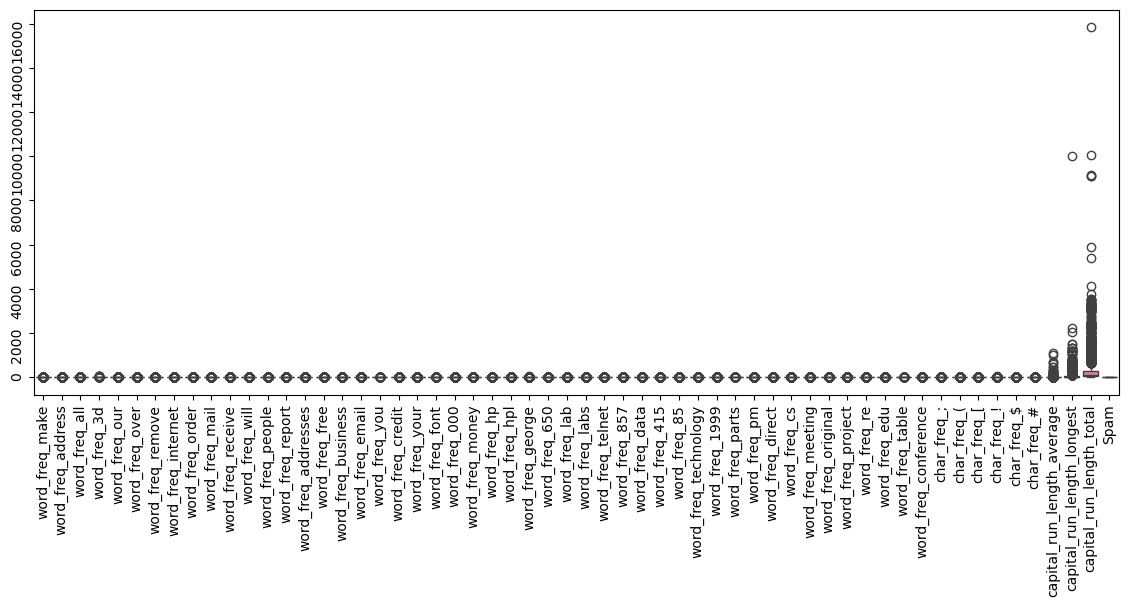

In [33]:
fig, ax = plt.subplots(figsize=(14,5))
sns.boxplot(data=cleaned_data)
ax.tick_params(labelrotation=90)

In [47]:
target_column="Spam"

In [48]:
features = cleaned_data.drop(columns=target_column)
target = cleaned_data[target_column]

In [56]:
# Class distribution
cleaned_data['Spam'].value_counts(normalize=True) # ~60% non-spam, ~40% spam

Spam
0    0.601188
1    0.398812
Name: proportion, dtype: float64

## Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=28, stratify=target)

In [50]:
len(X_train) == len(y_train)  # Check if X_train and y_train have the same number of rows

True

In [51]:
len(X_test) == len(y_test)  # Check if X_test and y_test have the same number of rows

True

In [58]:
y_train.value_counts(normalize=True)

Spam
0    0.601247
1    0.398753
Name: proportion, dtype: float64

In [59]:
y_test.value_counts(normalize=True)

Spam
0    0.60095
1    0.39905
Name: proportion, dtype: float64

## Pre-Processing

In [62]:
from sklearn.preprocessing import MinMaxScaler

In [71]:
scaler = MinMaxScaler()
# encoder = OrdinalEncoder()

In [72]:
scaler

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [73]:
from sklearn.compose import make_column_selector  # To select columns (Numerical, Categorical)
from sklearn.compose import ColumnTransformer  # To transform the columns

In [76]:
numeric_selector = make_column_selector(dtype_include='number')
#categorical_selector = make_column_selector(dtype_exclude='number')

In [75]:
numeric_columns = numeric_selector(features)
numeric_columns

['word_freq_make',
 'word_freq_address',
 'word_freq_all',
 'word_freq_3d',
 'word_freq_our',
 'word_freq_over',
 'word_freq_remove',
 'word_freq_internet',
 'word_freq_order',
 'word_freq_mail',
 'word_freq_receive',
 'word_freq_will',
 'word_freq_people',
 'word_freq_report',
 'word_freq_addresses',
 'word_freq_free',
 'word_freq_business',
 'word_freq_email',
 'word_freq_you',
 'word_freq_credit',
 'word_freq_your',
 'word_freq_font',
 'word_freq_000',
 'word_freq_money',
 'word_freq_hp',
 'word_freq_hpl',
 'word_freq_george',
 'word_freq_650',
 'word_freq_lab',
 'word_freq_labs',
 'word_freq_telnet',
 'word_freq_857',
 'word_freq_data',
 'word_freq_415',
 'word_freq_85',
 'word_freq_technology',
 'word_freq_1999',
 'word_freq_parts',
 'word_freq_pm',
 'word_freq_direct',
 'word_freq_cs',
 'word_freq_meeting',
 'word_freq_original',
 'word_freq_project',
 'word_freq_re',
 'word_freq_edu',
 'word_freq_table',
 'word_freq_conference',
 'char_freq_;',
 'char_freq_(',
 'char_freq_[',
 '

In [80]:
preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numeric_columns), 
    #('cat', encoder, categoric_columns)
])

In [81]:
preprocessor

,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


# Model Building

In [93]:
from sklearn.neighbors import KNeighborsClassifier

In [99]:
knn = KNeighborsClassifier()

In [100]:
from sklearn.pipeline import Pipeline

knn_model = Pipeline(steps=[
    ('preprocess', preprocessor), # For Preprocessing
    ('knn', knn) # For model training
])

Pipeline eliminates the need for storing transformed data manually before feeding it to model for training

## Hyper Parameter Tuning

What is a **Hyper Parameter**?

Parameters that are set before training the model.

For example, in KNeighboursClassifier(), 'n_neighbors', 'metrics', 'weight' are Hyper Parameters.

In [101]:
from sklearn.model_selection import GridSearchCV

In [124]:
param_grid = {"knn__n_neighbors": [3,5,7,9,11],
             "knn__weights": ["uniform", "distance"],
             "knn__metric": ["minkowski", "manhattan", "euclidean"]
            }

In [125]:
grid_search = GridSearchCV(estimator=knn_model,
                           param_grid=param_grid,
                           refit=True,  # Best model is fitted on entire training data
                           cv=5)

In [126]:
grid_search

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['minkowski', 'manhattan', ...], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [127]:
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__metric': ['minkowski', 'manhattan', ...], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [128]:
dir(grid_search)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_refit_for_multimetric',
 '_check_scorers_accept_sample_weight',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr

In [129]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__metric,param_knn__n_neighbors,param_knn__weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.025601,0.012077,0.027040,0.007233,minkowski,3,uniform,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.894659,0.890208,0.896142,0.894502,0.860327,0.887168,0.013566,19
1,0.017468,0.002945,0.020616,0.004409,minkowski,3,distance,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.905045,0.896142,0.903561,0.895988,0.866270,0.893401,0.014065,10
2,0.015589,0.001272,0.025967,0.006125,minkowski,5,uniform,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.888724,0.894659,0.887240,0.879643,0.869242,0.883902,0.008754,23
3,0.024620,0.003667,0.031243,0.008448,minkowski,5,distance,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.902077,0.896142,0.897626,0.895988,0.876672,0.893701,0.008795,7
4,0.015311,0.000821,0.021253,0.003165,minkowski,7,uniform,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.885757,0.884273,0.876855,0.869242,0.864785,0.876182,0.008193,27
5,0.019749,0.003984,0.020862,0.003305,minkowski,7,distance,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.899110,0.890208,0.891691,0.891530,0.875186,0.889545,0.007832,15
6,0.018302,0.004222,0.023081,0.004078,minkowski,9,uniform,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.887240,0.875371,0.887240,0.870728,0.870728,0.878262,0.007525,25
7,0.023649,0.004236,0.031835,0.009716,minkowski,9,distance,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.903561,0.885757,0.900593,0.890045,0.876672,0.891325,0.009828,12
8,0.019713,0.004116,0.027745,0.004665,minkowski,11,uniform,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.887240,0.878338,0.867953,0.864785,0.876672,0.874997,0.007972,29
9,0.016630,0.002231,0.024246,0.006581,minkowski,11,distance,"{'knn__metric': 'minkowski', 'knn__n_neighbors...",0.900593,0.885757,0.896142,0.884101,0.881129,0.889545,0.007489,17


In [132]:
best_model = grid_search.best_estimator_

In [133]:
best_model

,steps,"[('preprocess', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Evaluating the Model

## Train Performance

In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred_train = best_model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred_train)  # accuracy_score(y_true, y_pred)
precision = precision_score(y_train, y_pred_train)
recall = recall_score(y_train, y_pred_train)

In [137]:
print("Accuracy", accuracy)
print("Precision", precision)
print("Recall", recall)

Accuracy 0.9994061757719715
Precision 1.0
Recall 0.9985107967237528


## Test Performance

In [139]:
y_pred_test = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)  # accuracy_score(y_true, y_pred)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)

In [140]:
print("Accuracy", test_accuracy)
print("Precision", test_precision)
print("Recall", test_recall)

Accuracy 0.9144893111638955
Precision 0.9230769230769231
Recall 0.8571428571428571


## Confusion Metrics

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay

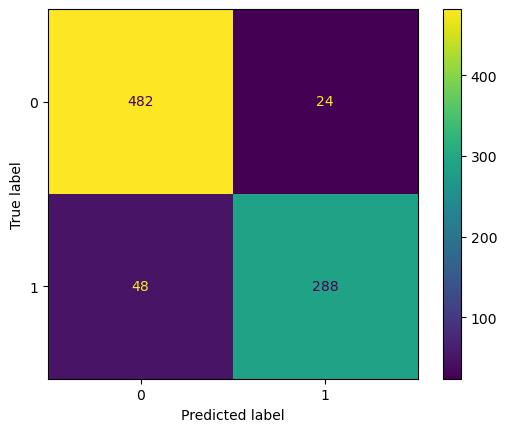

In [142]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)